In [1]:
import os
import shutil
import subprocess
import pandas as pd
import fastparquet
import kagglehub

DATA_DIR = "data"
CSV_FILE = os.path.join(DATA_DIR, "trending_yt_videos_113_countries.csv")
PARQUET_FILE = os.path.join(DATA_DIR, "youtube_data.parquet")
os.makedirs(DATA_DIR, exist_ok=True)

/Users/mccayruddick/Documents/Computer_Science/CSC487_Final/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if not os.path.exists(PARQUET_FILE) and not os.path.exists(CSV_FILE):
    print("Dataset not found locally. Downloading from Kaggle...")
    cache_path = kagglehub.dataset_download("asaniczka/trending-youtube-videos-113-countries/versions/852")
    
    # Find the CSV in the Kaggle cache and copy it to our data folder
    for file in os.listdir(cache_path):
        if file.endswith(".csv"):
            shutil.copy(os.path.join(cache_path, file), CSV_FILE)
            print(f"Successfully moved CSV to {CSV_FILE}")
else:
    print("CSV or Parquet already exists! Skipping download...........")

CSV or Parquet already exists! Skipping download...........


In [3]:
if not os.path.exists(PARQUET_FILE):
    print("Parquet file not found! preprocessing.........")
    result = subprocess.run(["python3", "process.py"], capture_output=True, text=True)
    
    if result.returncode == 0:
        print(result.stdout)
    else:
        print(result.stderr)
else:
    print("Parquet already exists! Ready!!!!")

Parquet already exists! Ready!!!!


In [4]:
df = pd.read_parquet(PARQUET_FILE)

print(f"DataFrame Shape: {df.shape}")
df.head()

DataFrame Shape: (4747142, 18)


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,video_id,channel_id,video_tags,kind,publish_date,langauge,like_tier
0,Nyasha David - Tsvodi (Official Music Video),Nyasha David,1,0,15,2026-02-18,ZW,430573,13860,1139,#Tsvodi #nyashadavid #mafindifuva \n\nSong Pro...,07pinMbPq2Q,UCx1LPxEtJWIpvtXTYadAdKg,,youtube#video,2026-02-09,und,pretty_viral
1,WAR MACHINE | Official Trailer | Netflix,Netflix,2,0,0,2026-02-18,ZW,12531660,191591,15336,During the final stage of U.S. Army Ranger sel...,AFuE1LRxm80,UCWOA1ZGywLbqmigxE4Qlvuw,"Alan Ritchson, Alan Ritchson War Machine, Armo...",youtube#video,2026-02-04,en-US,really_viral
2,10 Seconds vs 1 Hour MODERN MOUNTAIN HOUSE Bui...,Cash,3,0,47,2026-02-18,ZW,491455,6139,1656,Instagram: https://www.instagram.com/cashmarco...,EbBjlznDwzk,UC0eLBYhxW9HC0P9PXQ73mpQ,"Cash, Nico, Nico and Cash, Cash and Nico, Mine...",youtube#video,2026-02-16,en-US,a_little_viral
3,Master H - Impossible (Official Music Video),Master H,4,0,3,2026-02-18,ZW,532388,14552,1281,Artist : Master H\nSong : Impossible \nProduce...,TIG5IzusQ24,UC5jrU8WxzE16gPTnlqQAqew,,youtube#video,2026-02-06,en,pretty_viral
4,“Spider-Noir” – Authentic Black & White Teaser...,Prime Video,5,0,45,2026-02-18,ZW,13406903,239798,10614,"With no power comes no responsibility. ""Spider...",HgMbkitzhEM,UCQJWtTnAHhEG5w4uN0udnUQ,"spider noir official teaser, spider noir tease...",youtube#video,2026-02-12,en,really_viral


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4747142 entries, 0 to 4747141
Data columns (total 18 columns):
 #   Column           Dtype         
---  ------           -----         
 0   title            object        
 1   channel_name     object        
 2   daily_rank       uint8         
 3   daily_movement   int16         
 4   weekly_movement  int16         
 5   snapshot_date    datetime64[us]
 6   country          object        
 7   view_count       int64         
 8   like_count       int32         
 9   comment_count    int32         
 10  description      object        
 11  video_id         object        
 12  channel_id       object        
 13  video_tags       object        
 14  kind             object        
 15  publish_date     datetime64[us]
 16  langauge         object        
 17  like_tier        object        
dtypes: datetime64[us](2), int16(2), int32(2), int64(1), object(10), uint8(1)
memory usage: 529.7+ MB


In [6]:
df.shape
df.describe()

,daily_rank,daily_movement,weekly_movement,snapshot_date,view_count,like_count,comment_count,publish_date
count,4.747142e+06,4.747142e+06,4.747142e+06,4747142,4.747142e+06,4.747142e+06,4.747142e+06,4747142
mean,2.544879e+01,2.704673e+00,1.726932e+01,2024-12-21 02:29:18.085180,1.055349e+07,3.259516e+05,6.881398e+03,2024-12-14 17:56:09.078039
min,1.000000e+00,-4.900000e+01,-4.900000e+01,2023-10-26 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,2023-09-20 02:22:46
25%,1.300000e+01,-8.000000e+00,4.000000e+00,2024-05-24 00:00:00,3.185920e+05,8.830000e+03,2.920000e+02,2024-05-18 00:00:00
50%,2.500000e+01,-1.000000e+00,2.000000e+01,2024-12-21 00:00:00,1.305670e+06,4.323500e+04,1.089000e+03,2024-12-14 00:00:00
75%,3.800000e+01,1.200000e+01,3.500000e+01,2025-07-19 00:00:00,8.235680e+06,2.519460e+05,3.624000e+03,2025-07-12 00:00:00
max,5.000000e+01,4.900000e+01,4.900000e+01,2026-02-18 00:00:00,1.407108e+09,1.576806e+07,6.493188e+06,2026-02-18 00:00:00
std,1.442901e+01,1.862639e+01,2.203937e+01,NaN,2.440221e+07,7.961383e+05,4.944094e+04,NaN


In [7]:
df.sample(5)


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,video_id,channel_id,video_tags,kind,publish_date,langauge,like_tier
1779373,“Nu vorbesc des cu soacra mea!” - Andreea Tonc...,JORGE OFFICIAL,18,9,32,2025-04-05,RO,93941,2427,44,,4LCx1T0TTuc,UCcmg1N05paxrxKc0RYZcMrQ,,youtube#video,2025-04-03,ro,a_little_viral
3179138,Як морпіхи ЗСУ проривалися на «Азовсталь» на м...,Радіо Свобода,21,-7,29,2024-07-31,UA,1180606,65624,738,Морпіхи 36 бригади ЗСУ розповіли у інтерв'ю Ра...,m2JUBG833KU,UC7qnYpVcuFbURi3E2E6_f6Q,"прорив на азовсталь, морпіхи зсу, зсу, оборона...",youtube#video,2024-07-22,uk,really_viral
1986464,IS THIS THE BEST BRAWLER EVER?!,Brawl Stars,21,15,29,2025-02-28,BO,14533312,503769,53091,"IMPROVED REWARDS FOR F2P, A FULL RANKED REWORK...",SD2UiX1jpd8,UCooVYzDxdwTtGYAkcPmOgOw,"brawl stars, mobile game, mobile strategy game...",youtube#video,2025-02-22,en,super_viral
790899,The Witcher Season 4 - Is Anyone Still Watchin...,The Critical Drinker,26,3,-12,2025-09-29,IL,1389401,84764,8684,The recent trailer for Witcher Season 4 on Net...,IKNLiyGCa9I,UCSJPFQdZwrOutnmSFYtbstA,"critical drinker, review, funny, best movie re...",youtube#video,2025-09-17,en,really_viral
3585205,Scharfe Kritik! DOPA-Gäste wegen Tuchel in Rage,SPORT1,18,32,32,2024-05-20,AT,430589,2926,742,Hätte Thomas Tuchel beim FC Bayern bleiben sol...,CdzIBzA4C_g,UCPj_Vtw0hKnhJapQuATBUrA,"SPORT1, Sport, sport1news, fussball, daum, tuc...",youtube#video,2024-05-19,de,a_little_viral


In [8]:
df.isna().sum()


title              0
channel_name       0
daily_rank         0
daily_movement     0
weekly_movement    0
snapshot_date      0
country            0
view_count         0
like_count         0
comment_count      0
description        0
video_id           0
channel_id         0
video_tags         0
kind               0
publish_date       0
langauge           0
like_tier          0
dtype: int64

In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# Get the oldest date
oldest_date = df['publish_date'].min()

# Get the newest date
newest_date = df['publish_date'].max()

print(f"Oldest: {oldest_date}")
print(f"Newest: {newest_date}")

Oldest: 2023-09-20 02:22:46
Newest: 2026-02-18 00:00:00


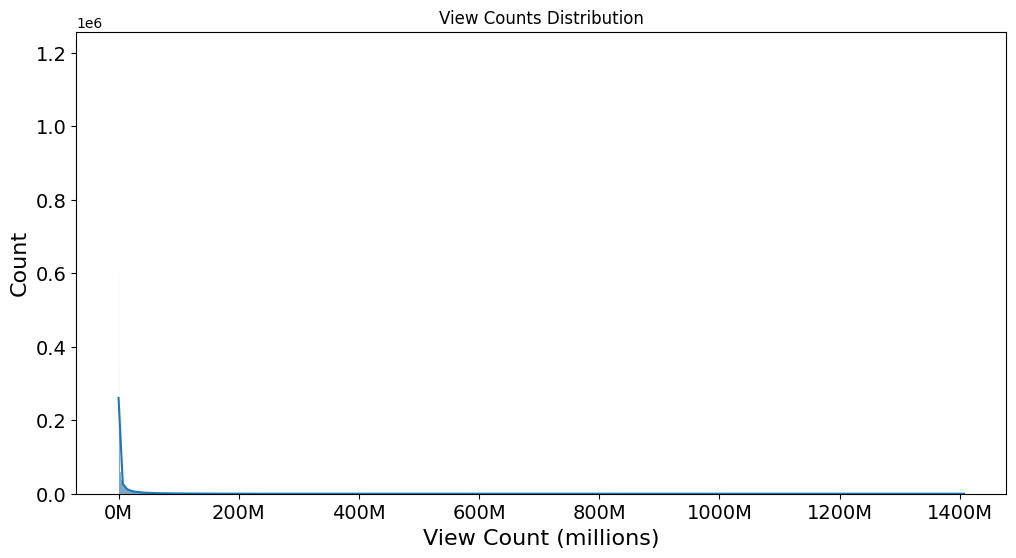

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


df['publish_month'] = df['publish_date'].dt.month
df['publish_day'] = df['publish_date'].dt.day
df['publish_year'] = df['publish_date'].dt.year

plt.figure(figsize=(12,6))
sns.histplot(df['view_count'], kde=True)
plt.title('View Counts Distribution')

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('View Count (millions)', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.show()

/Users/mccayruddick/Documents/Computer_Science/CSC487_Final/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


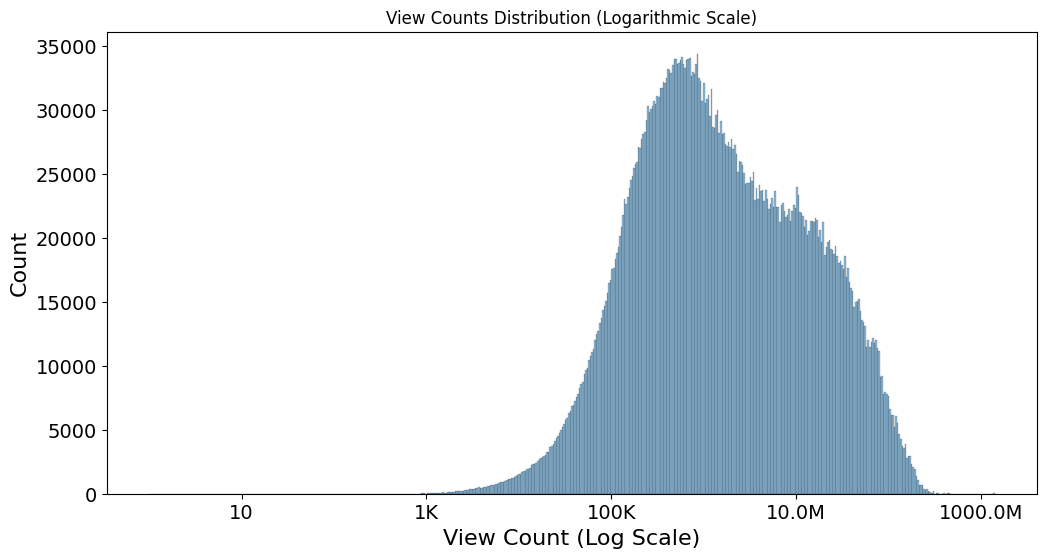

In [12]:
plt.figure(figsize=(12, 6))
ax = plt.gca() 

sns.histplot(df['view_count'], kde=True, log_scale=True)

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('View Count (Log Scale)', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.title('View Counts Distribution (Logarithmic Scale)')

plt.show()

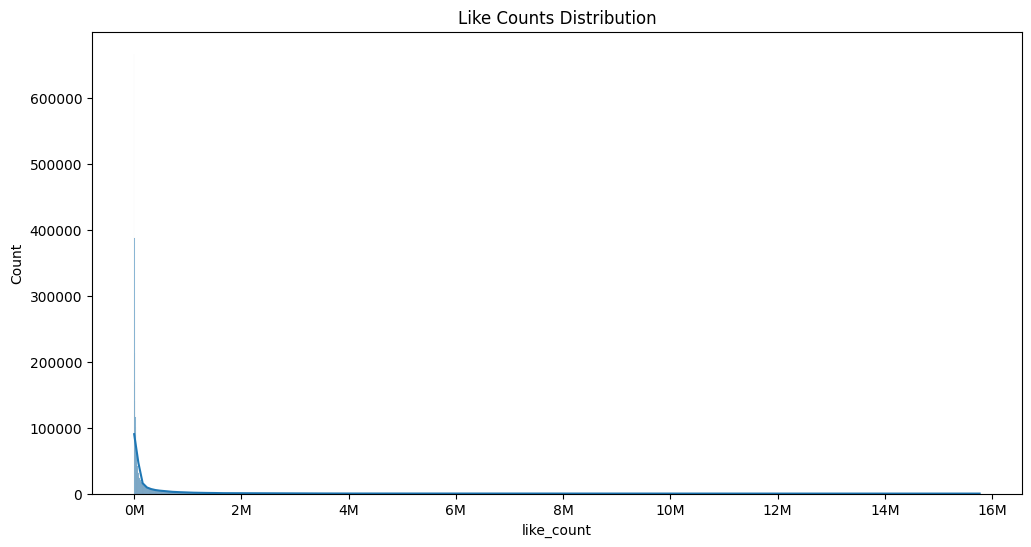

In [13]:
plt.figure(figsize=(12, 6))
ax = plt.gca() 
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

sns.histplot(df['like_count'], kde=True)
plt.title('Like Counts Distribution')
plt.show()

/Users/mccayruddick/Documents/Computer_Science/CSC487_Final/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


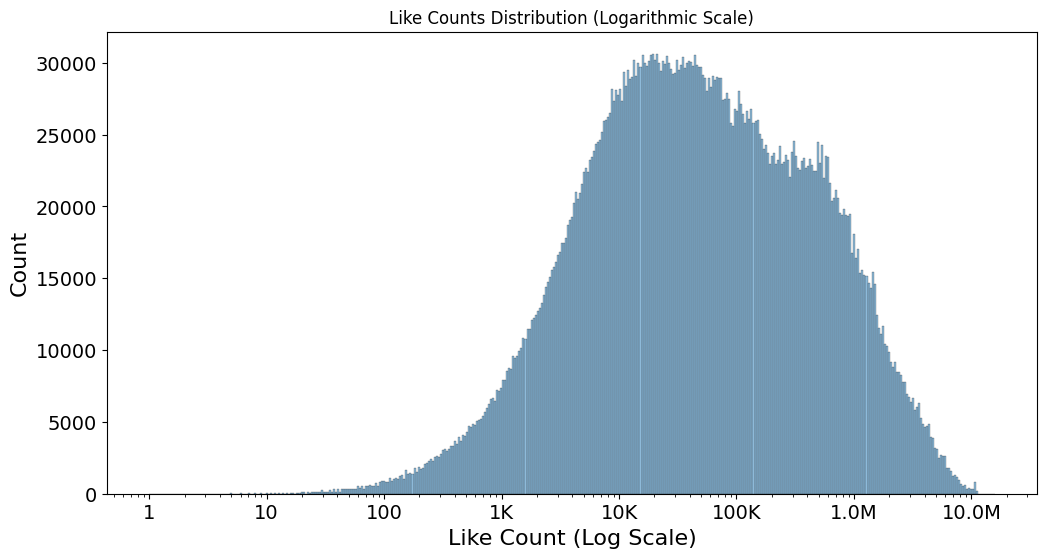

In [14]:
plt.figure(figsize=(12, 6))
ax = plt.gca() 

sns.histplot(df['like_count'], kde=True, log_scale=True)

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Like Count (Log Scale)', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.title('Like Counts Distribution (Logarithmic Scale)')

plt.show()

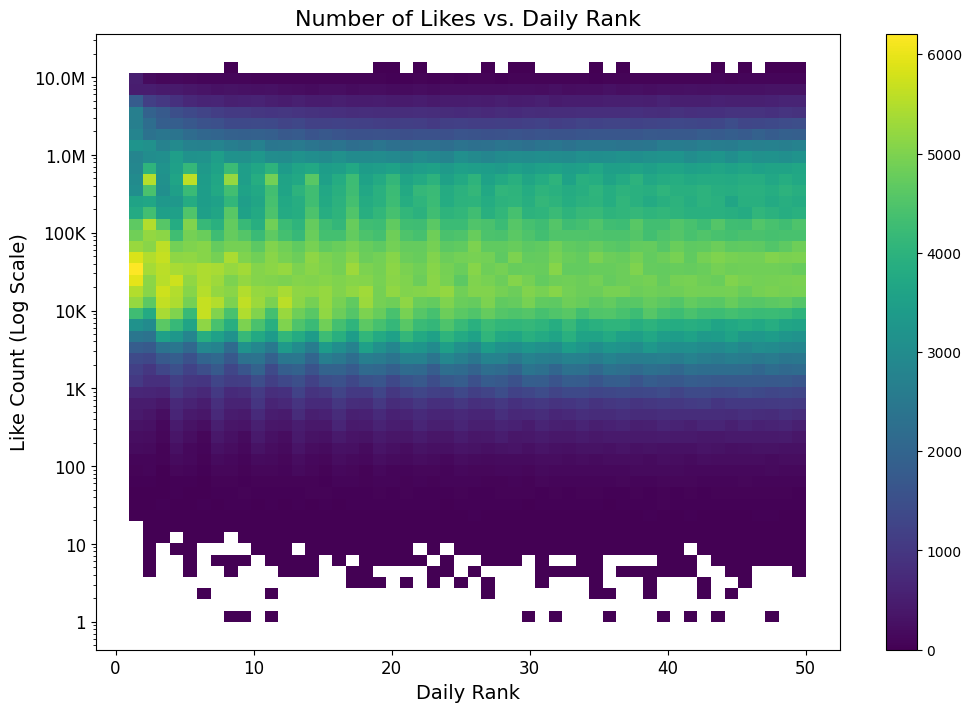

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

plt.figure(figsize=(12, 8))

df_filtered = df[df['like_count'] > 0]

sns.histplot(
    data=df_filtered, 
    x='daily_rank', 
    y='like_count', 
    log_scale=(False, True),
    bins=50, 
    cbar=True,
    cmap='viridis'
)

ax = plt.gca()

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.title('Number of Likes vs. Daily Rank', fontsize=16)
plt.xlabel('Daily Rank', fontsize=14)
plt.ylabel('Like Count (Log Scale)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

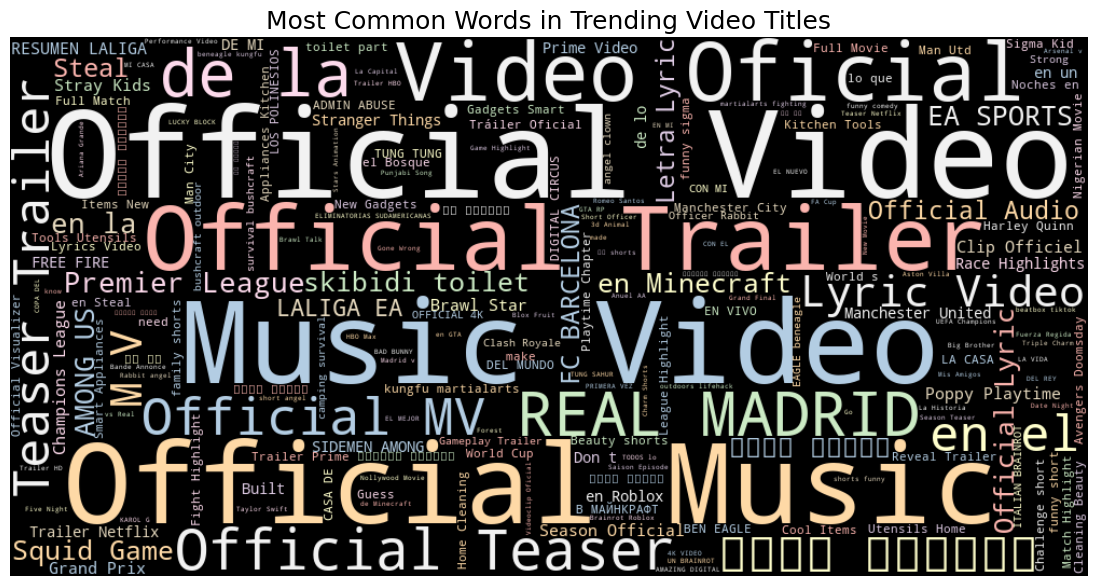

In [16]:
import plotly.express as px
from wordcloud import WordCloud


text = ' '.join(df['title'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='black', colormap='Pastel1').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Trending Video Titles", fontsize=18)
plt.show()

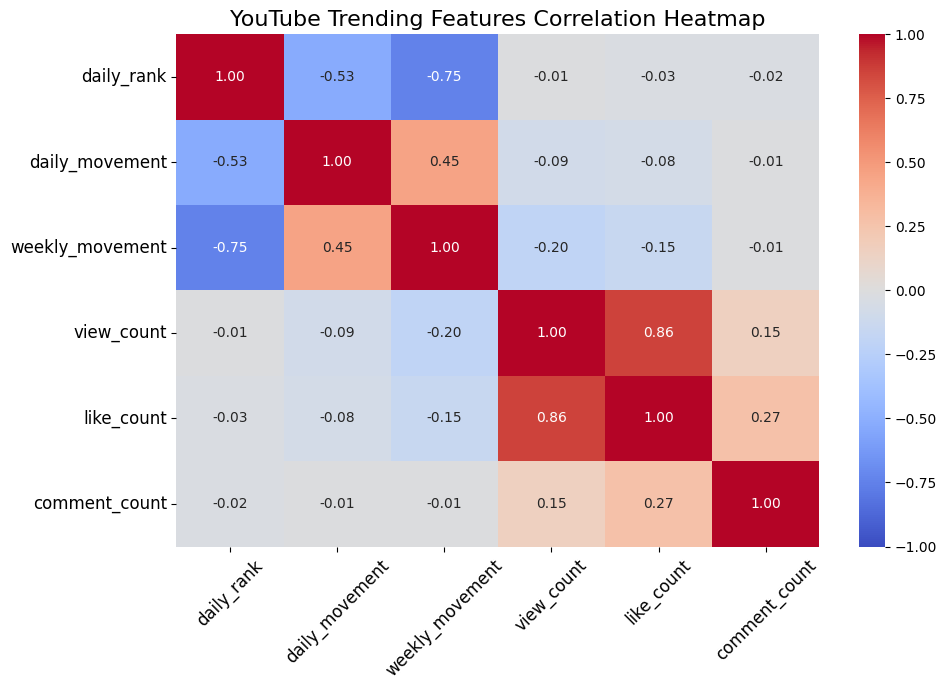

In [17]:
corr_df = df[["daily_rank", "daily_movement", "weekly_movement", "view_count", "like_count", "comment_count"]]

corr_matrix = corr_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("YouTube Trending Features Correlation Heatmap", fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

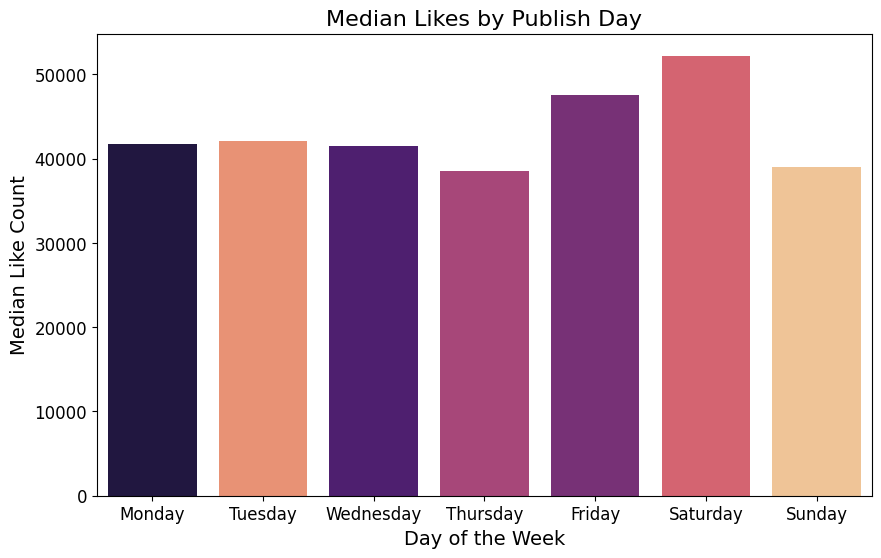

In [21]:
import pandas as pd

df['publish_day_of_week'] = df['publish_date'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df, 
    x='publish_day_of_week', 
    y='like_count', 
    order=days_order,
    estimator='median',
    errorbar=None,
    hue='publish_day_of_week',
    palette='magma',
    legend=False
)

plt.title('Median Likes by Publish Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Median Like Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

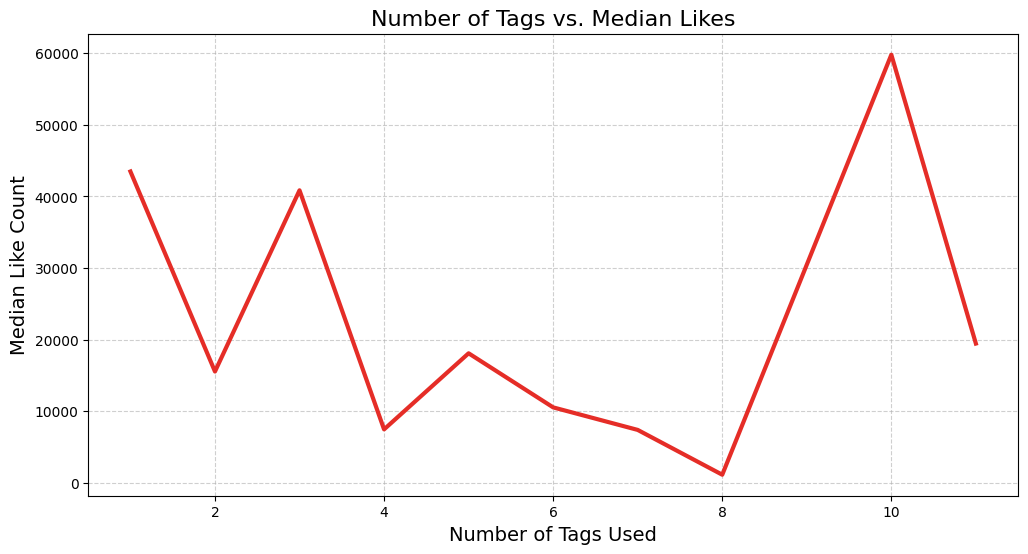

In [19]:
import numpy as np

df['tag_count'] = df['video_tags'].astype(str).str.split('|').str.len().fillna(0)
tag_grouped = df.groupby('tag_count')['like_count'].median().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=tag_grouped, 
    x='tag_count', 
    y='like_count', 
    linewidth=3,
    color='#e52d27'
)

plt.title('Number of Tags vs. Median Likes', fontsize=16)
plt.xlabel('Number of Tags Used', fontsize=14)
plt.ylabel('Median Like Count', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

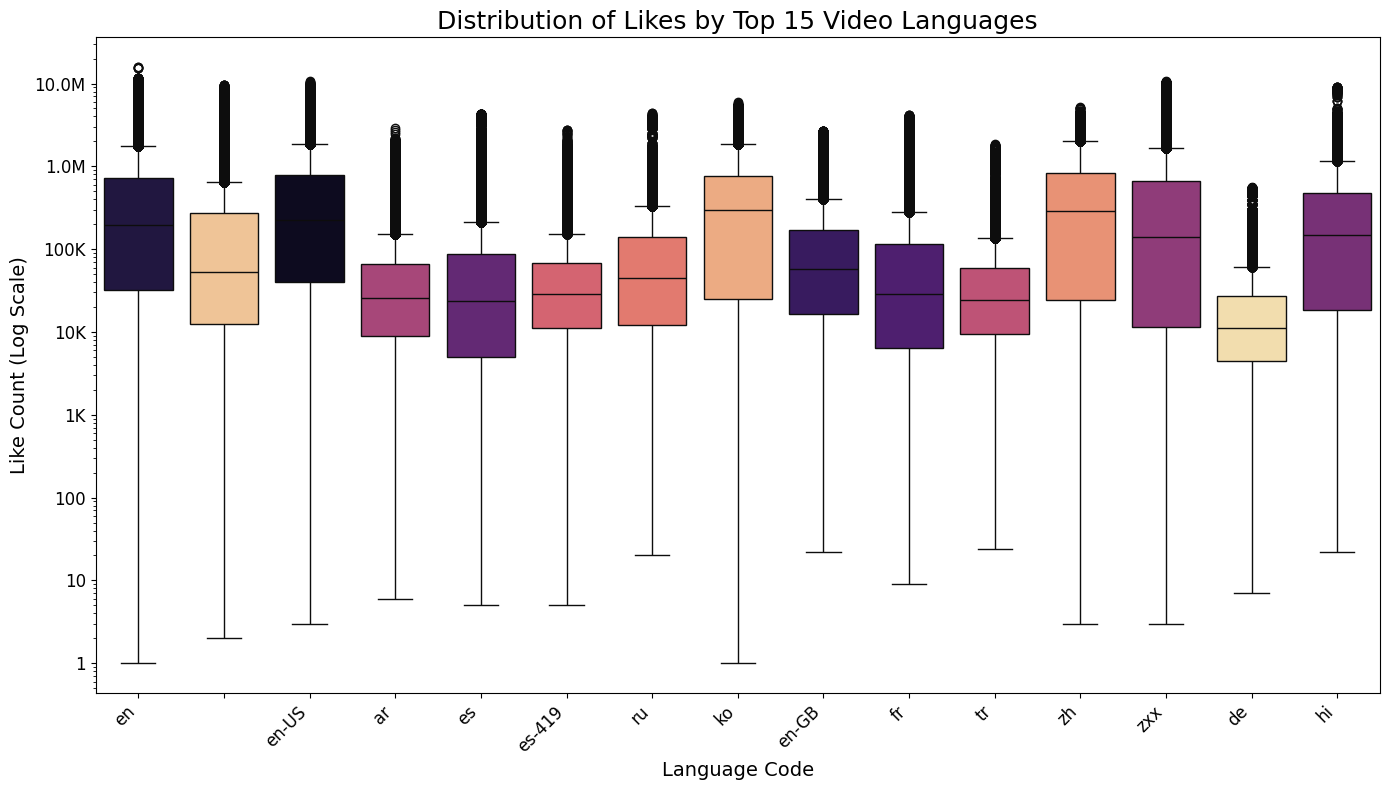

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

top_15_languages = df['langauge'].value_counts().nlargest(15).index
df_filtered = df[(df['langauge'].isin(top_15_languages)) & (df['like_count'] > 0)]

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_filtered, 
    x='langauge', 
    y='like_count', 
    order=top_15_languages,
    hue='langauge',
    palette='magma',
    legend=False
)

ax = plt.gca()

ax.set_yscale('log')

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.title('Distribution of Likes by Top 15 Video Languages', fontsize=18)
plt.xlabel('Language Code', fontsize=14)
plt.ylabel('Like Count (Log Scale)', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()